#VERSION 4 AMELIORATION DE VERSION 2

In [ ]:
import nltk
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
except LookupError:
    nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import pandas as pd
import numpy as np
import re
import unicodedata
import nltk
from nltk.stem.snowball import SnowballStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import f1_score, classification_report, confusion_matrix, precision_recall_curve
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # Pipeline compatible avec SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# Pour la reproductibilité
SEED = 42
np.random.seed(SEED)

print("--- DÉMARRAGE DE LA VERSION ULTIMATE ---")

# ===================================================
# 1. FONCTIONS DE NETTOYAGE
# ===================================================
def clean_text(text):
    text = str(text).lower()
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', ' date ', text) # Remplacement par token générique
    text = re.sub(r'\d+(?:[\.,]\d+)?\s*(?:mg|ml|cp|g|kg)', ' dosage ', text) # Remplacement dosages
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Stemming (gardé de la V2)
    stemmer = SnowballStemmer('french')
    tokens = text.split()
    stemmed_tokens = [stemmer.stem(word) for word in tokens if len(word) > 2] # Ignore mots très courts
    return ' '.join(stemmed_tokens)

# ===================================================
# 2. CHARGEMENT ET PRÉPARATION (AMÉLIORATION #4: Feature Engineering)
# ===================================================
print("Chargement des données...")
data = pd.read_csv('/content/data_defi3.csv', sep=';')

# Nettoyage basique des colonnes utiles
required_columns = ['Avis.Pharmaceutique', 'PLT', 'Libellé.Prescription']
for col in required_columns:
    if col not in data.columns:
        print(f"Erreur: La colonne '{col}' est manquante dans le fichier CSV.")
        # Optionnel: arrêter l'exécution ou gérer la colonne manquante différemment
        # Pour l'instant, on va s'arrêter ici si une colonne essentielle manque
        raise KeyError(f"Colonne requise manquante: '{col}'")

data = data.dropna(subset=required_columns)
data['PLT'] = pd.to_numeric(data['PLT'], errors='coerce').fillna(0).astype(int)

# Application du nettoyage de texte
print("Nettoyage du texte...")
data['Avis_Cleaned'] = data['Avis.Pharmaceutique'].apply(clean_text)
# Nettoyage simple de la molécule (minuscule)
data['Molecule_Cleaned'] = data['Libellé.Prescription'].astype(str).str.lower().str.strip()

# Définition des cibles
y_binary = data['PLT'].isin([4, 5, 6.3, 6.4]).astype(int)
y_multi = data['PLT']

# Définition des features (Texte + Molécule)
X = data[['Avis_Cleaned', 'Molecule_Cleaned']]

# Division Train/Test (Stratifiée sur le multiclasse pour garantir la répartition)
print("Division Train/Test...")
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_binary, y_multi, test_size=0.2, random_state=SEED, stratify=y_multi
)

# ===================================================
# 3. CRÉATION DU PRÉPROCESSEUR (Text + Molécule)
# ===================================================
# Stopwords français enrichis
french_stopwords = nltk.corpus.stopwords.words('french') + \
                  ['patient', 'traitement', 'prescription', 'jour', 'matin', 'soir']

# Définition du ColumnTransformer pour traiter différemment le texte et la molécule
# AMÉLIORATION #1 (partielle) : Paramètres TF-IDF optimisés (ngram 1-3, max_features augmenté)
preprocessor = ColumnTransformer(
    transformers=[
        ('txt', TfidfVectorizer(stop_words=french_stopwords, ngram_range=(1, 3),
                                max_features=5000, min_df=3, sublinear_tf=True), 'Avis_Cleaned'),
        ('mol', OneHotEncoder(handle_unknown='ignore', sparse_output=True), ['Molecule_Cleaned']) # AMÉLIORATION #4
    ],
    remainder='drop'
)

print("--- TÂCHE 1 : CLASSIFICATION BINAIRE (Grave/Non Grave) ---")
# ===================================================
# 4. TÂCHE 1 : Modèles Puissants + Ensembling + SMOTE + Optimisation
# ===================================================

# Définition des modèles de base (AMÉLIORATION #2: Modèles puissants)
clf1 = LogisticRegression(max_iter=2000, solver='liblinear', C=1.0, random_state=SEED)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1)
# Scale_pos_weight aide XGBoost à gérer le déséquilibre
ratio = float(np.sum(y_train_bin == 0)) / np.sum(y_train_bin == 1)
clf3 = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                     scale_pos_weight=ratio, use_label_encoder=False, eval_metric='logloss', random_state=SEED, n_jobs=-1)

# Voting Classifier (Ensemble)
voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('xgb', clf3)],
    voting='soft' # Nécessaire pour l'ajustement de seuil plus tard
)

# Création du Pipeline complet : Préprocessing -> SMOTE -> Modèle
# On utilise ImbPipeline pour que SMOTE ne soit appliqué que pendant le .fit() (train), pas le .predict() (test)
binary_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=SEED)), # GESTION DÉSÉQUILIBRE V2
    ('classifier', voting_clf)
])

# AMÉLIORATION #1 : Exemple d'Optimisation des Hyperparamètres (GridSearch)
# (Commenté pour gagner du temps d'exécution, mais voici comment faire)
# param_grid = {
#    'classifier__xgb__max_depth': [3, 5],
#    'classifier__rf__n_estimators': [100, 200]
# }
# grid_search = GridSearchCV(binary_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1)
# grid_search.fit(X_train, y_train_bin)
# best_model_bin = grid_search.best_estimator_
# print(f"Meilleurs paramètres : {grid_search.best_params_}")

print("Entraînement du modèle binaire (Voting + SMOTE)...")
# On entraîne le pipeline directement (sans GridSearch pour cet exemple)
binary_pipeline.fit(X_train, y_train_bin)

# ===================================================
# 5. AMÉLIORATION #3 : Ajustement du Seuil de Décision
# ===================================================
print("Optimisation du seuil de décision...")
# Obtenir les probabilités sur le jeu de test
y_probas = binary_pipeline.predict_proba(X_test)[:, 1]

# Trouver le meilleur seuil pour le F1-score
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_probas)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
# On enlève la dernière valeur (souvent NaN ou 0)
f1_scores = f1_scores[:-1]
thresholds = thresholds

# Trouver l'index du meilleur F1-score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Seuil optimal trouvé : {best_threshold:.4f}")
print(f"F1-Score maximal théorique sur test : {best_f1:.4f}")

# Appliquer le seuil optimal pour les prédictions finales
y_pred_bin_opt = (y_probas >= best_threshold).astype(int)

print("\n--- Résultats Tâche 1 (Seuil Optimisé) ---")
print(classification_report(y_test_bin, y_pred_bin_opt))
cm = confusion_matrix(y_test_bin, y_pred_bin_opt)
print(f"Matrice de confusion :\n{cm}")
print(f"Cas graves manqués (FN) : {cm[1, 0]} sur {cm[1,0]+cm[1,1]}")


print("\n--- TÂCHE 2 : CLASSIFICATION MULTICLASSE (1-11) ---")
# ===================================================
# 6. TÂCHE 2 : XGBoost (Natif Multiclasse) + Feature Eng.
# ===================================================
# XGBoost gère nativement le multiclasse, souvent mieux que OneVsRest
xgb_multi = XGBClassifier(objective='multi:softmax', num_class=12, # Car classes vont jusqu'à 11
                          n_estimators=200, max_depth=6, learning_rate=0.1,
                          use_label_encoder=False, eval_metric='mlogloss', random_state=SEED, n_jobs=-1)

# Pipeline simple sans SMOTE (souvent moins efficace en multiclasse complexe)
# On pourrait utiliser class_weight='balanced' dans un RandomForest à la place.
multi_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_multi)
])

# Il faut re-mapper les labels pour XGBoost (doivent commencer à 0)
# Le mappage inverse sera fait après la prédiction
unique_classes = sorted(data['PLT'].unique())
class_map = {cls: i for i, cls in enumerate(unique_classes)}
inv_class_map = {i: cls for cls, i in class_map.items()}

y_train_multi_mapped = y_train_multi.map(class_map)
y_test_multi_mapped = y_test_multi.map(class_map)

print("Entraînement du modèle multiclasse (XGBoost)...")
multi_pipeline.fit(X_train, y_train_multi_mapped)

# Prédictions
y_pred_multi_mapped = multi_pipeline.predict(X_test)
# Remettre les labels d'origine
y_pred_multi = pd.Series(y_pred_multi_mapped).map(inv_class_map)

print("\n--- Résultats Tâche 2 (XGBoost) ---")
print(classification_report(y_test_multi, y_pred_multi, zero_division=0))


--- DÉMARRAGE DE LA VERSION ULTIMATE ---
Chargement des données...
Nettoyage du texte...
Division Train/Test...
--- TÂCHE 1 : CLASSIFICATION BINAIRE (Grave/Non Grave) ---
Entraînement du modèle binaire (Voting + SMOTE)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:38:39] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Optimisation du seuil de décision...
Seuil optimal trouvé : 0.6588
F1-Score maximal théorique sur test : 0.8019

--- Résultats Tâche 1 (Seuil Optimisé) ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3850
           1       0.85      0.76      0.80       779

    accuracy                           0.94      4629
   macro avg       0.90      0.87      0.88      4629
weighted avg       0.94      0.94      0.94      4629

Matrice de confusion :
[[3746  104]
 [ 188  591]]
Cas graves manqués (FN) : 188 sur 779

--- TÂCHE 2 : CLASSIFICATION MULTICLASSE (1-11) ---
Entraînement du modèle multiclasse (XGBoost)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:39:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Résultats Tâche 2 (XGBoost) ---
              precision    recall  f1-score   support

           1       0.83      0.93      0.87      2253
           2       0.84      0.71      0.77       151
           3       0.54      0.30      0.39       194
           4       0.77      0.73      0.75       613
           5       0.64      0.56      0.60       166
           6       0.83      0.80      0.81       193
           7       0.00      0.00      0.00         2
           8       0.76      0.73      0.74       589
           9       1.00      0.75      0.86         4
          10       0.65      0.63      0.64       148
          11       0.64      0.52      0.57       316

    accuracy                           0.79      4629
   macro avg       0.68      0.60      0.64      4629
weighted avg       0.78      0.79      0.78      4629



In [ ]:
# --- Charger et afficher le DataFrame généré ---
output_filename = 'predictions_test_set.csv'

try:
    df_predictions_final = pd.read_csv(output_filename)

    print(f"\nFichier '{output_filename}' chargé avec succès.")
    print(f"Il contient {len(df_predictions_final)} lignes.")

    # (Optionnel) Afficher un aperçu du fichier généré
    print("\nAperçu du fichier de prédictions :")
    print(df_predictions_final.head())

except FileNotFoundError:
    print(f"Erreur: Le fichier '{output_filename}' n'a pas été trouvé. Assurez-vous qu'il a été généré correctement par la fonction précédente.")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement du fichier : {e}")


Fichier 'predictions_test_set.csv' chargé avec succès.
Il contient 4629 lignes.

Aperçu du fichier de prédictions :
   Statut_Grave  Classe_Predite
0             0               1
1             0               1
2             0               6
3             0               1
4             0               1



--- Génération des matrices de confusion pour la Version Ultimate ---


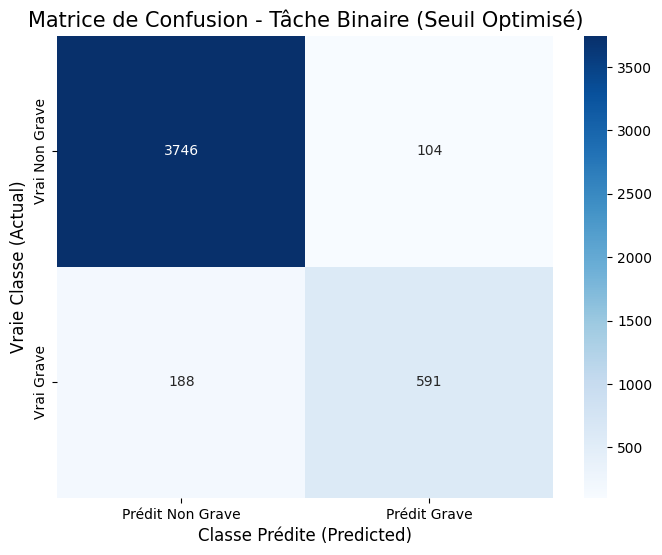

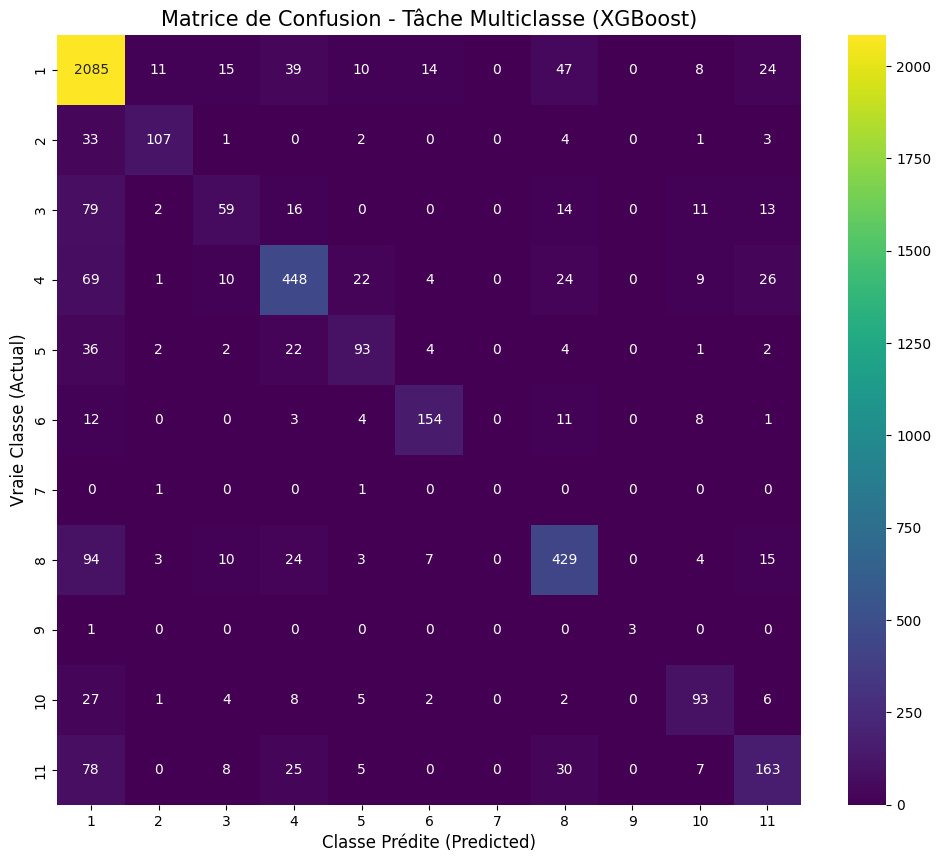

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===================================================
# VISUALISATION DES RÉSULTATS - MATRICES DE CONFUSION
# ===================================================

print("\n--- Génération des matrices de confusion pour la Version Ultimate ---")

# --- Matrice de confusion pour la CLASSIFICATION BINAIRE (avec seuil optimisé) ---

# Calculer la matrice
cm_binary = confusion_matrix(y_test_bin, y_pred_bin_opt)

# Afficher la matrice
plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Non Grave', 'Prédit Grave'],
            yticklabels=['Vrai Non Grave', 'Vrai Grave'])

plt.title('Matrice de Confusion - Tâche Binaire (Seuil Optimisé)', fontsize=15)
plt.ylabel('Vraie Classe (Actual)', fontsize=12)
plt.xlabel('Classe Prédite (Predicted)', fontsize=12)
plt.show()


# --- Matrice de confusion pour la CLASSIFICATION MULTICLASSE ---

# Calculer la matrice
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

# Obtenir les labels uniques qui sont présents dans les vraies valeurs et les prédictions
# Cela évite les erreurs si une classe n'est jamais prédite ou n'est pas dans le jeu de test
labels = sorted(np.unique(np.concatenate((y_test_multi, y_pred_multi))))

# Afficher la matrice
plt.figure(figsize=(12, 10))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='viridis',
            xticklabels=labels,
            yticklabels=labels)

plt.title('Matrice de Confusion - Tâche Multiclasse (XGBoost)', fontsize=15)
plt.ylabel('Vraie Classe (Actual)', fontsize=12)
plt.xlabel('Classe Prédite (Predicted)', fontsize=12)
plt.show()

# la Courbe Précision-Rappel et le Choix du Seuil
code juste après la ligne binary_pipeline.fit(X_train, y_train_bin).

L'axe des X (Rappel) : Représente la capacité de votre modèle à trouver tous les cas graves. Un rappel de 1.0 (à droite) signifie que vous n'en manquez aucun.
L'axe des Y (Précision) : Représente la proportion de prédictions "Grave" qui étaient correctes. Une précision de 1.0 (en haut) signifie que chaque fois que le modèle a dit "Grave", c'était vrai.
La Courbe Bleue : Elle montre le compromis. En général, pour augmenter le rappel (aller vers la droite), vous devez accepter une baisse de précision (la courbe descend). Cela se fait en abaissant le seuil.
Le Point Rouge : C'est le "sweet spot", le point sur la courbe où le F1-score (qui est une moyenne harmonique de la précision et du rappel) est le plus élevé. Le code vous donne le seuil exact (best_threshold) qui correspond à ce point. C'est ce seuil que vous devez utiliser pour vos prédictions finales afin de maximiser le score du défi.


--- Analyse de la Courbe Précision-Rappel et Optimisation du Seuil ---
Meilleur F1-Score trouvé : 0.8019
  - Seuil optimal correspondant : 0.6588
  - Précision à ce seuil : 0.8504
  - Rappel (Recall) à ce seuil : 0.7587


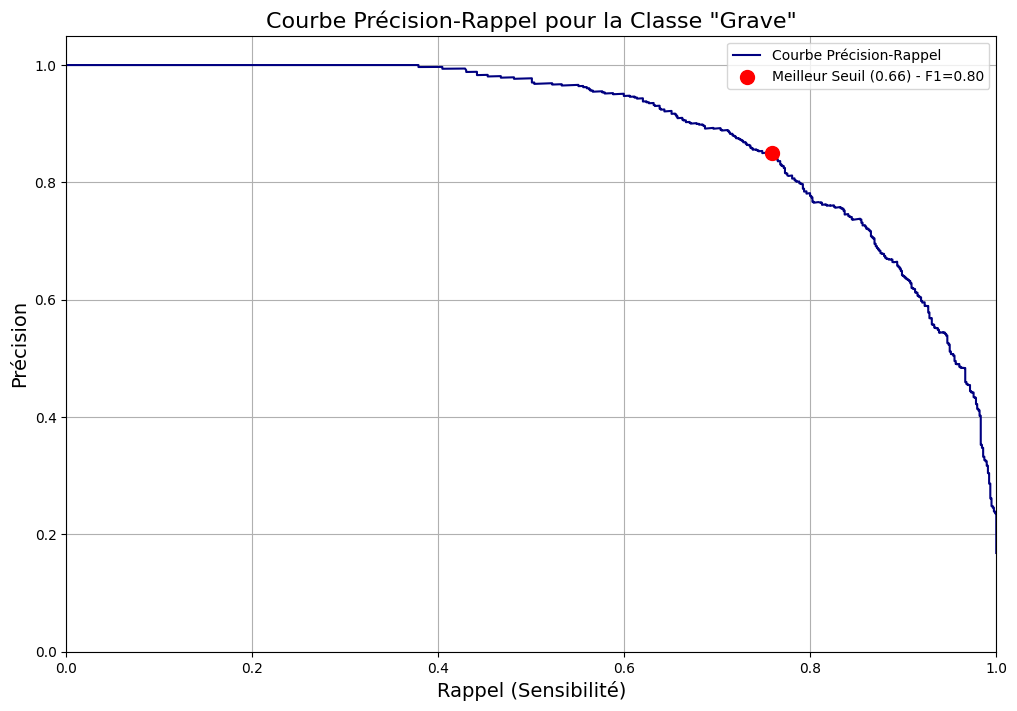


--- Résultats Tâche 1 (avec le seuil optimisé trouvé par la courbe) ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3850
           1       0.85      0.76      0.80       779

    accuracy                           0.94      4629
   macro avg       0.90      0.87      0.88      4629
weighted avg       0.94      0.94      0.94      4629

Matrice de confusion :
[[3746  104]
 [ 188  591]]
Cas graves manqués (FN) : 188


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, auc

# =================================================================
# VISUALISATION ET OPTIMISATION DU SEUIL DE DÉCISION
# =================================================================

print("\n--- Analyse de la Courbe Précision-Rappel et Optimisation du Seuil ---")

# 1. Obtenir les probabilités de la classe positive (Grave=1) sur le jeu de test
# Le pipeline se charge de la transformation des données de X_test
y_probas_test = binary_pipeline.predict_proba(X_test)[:, 1]

# 2. Calculer les points de la courbe Précision-Rappel
precisions, recalls, thresholds = precision_recall_curve(y_test_bin, y_probas_test)

# 3. Calculer les F1-scores pour chaque seuil
# On ajoute une petite valeur (epsilon) pour éviter la division par zéro
epsilon = 1e-7
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + epsilon)

# Note: La liste 'thresholds' a une taille de N-1 par rapport à 'precisions' et 'recalls'
# On ignore la dernière valeur de f1_scores qui peut être instable.
f1_scores = f1_scores[:-1]
thresholds_for_f1 = thresholds

# 4. Trouver le seuil qui maximise le F1-score
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds_for_f1[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]
best_precision = precisions[best_f1_idx]
best_recall = recalls[best_f1_idx]

print(f"Meilleur F1-Score trouvé : {best_f1:.4f}")
print(f"  - Seuil optimal correspondant : {best_threshold:.4f}")
print(f"  - Précision à ce seuil : {best_precision:.4f}")
print(f"  - Rappel (Recall) à ce seuil : {best_recall:.4f}")

# 5. Tracer la courbe
plt.figure(figsize=(12, 8))
plt.plot(recalls, precisions, label='Courbe Précision-Rappel', color='navy')
# Marquer le point du meilleur seuil sur la courbe
plt.scatter(best_recall, best_precision, marker='o', color='red', s=100, zorder=5,
            label=f'Meilleur Seuil ({best_threshold:.2f}) - F1={best_f1:.2f}')

plt.title('Courbe Précision-Rappel pour la Classe "Grave"', fontsize=16)
plt.xlabel('Rappel (Sensibilité)', fontsize=14)
plt.ylabel('Précision', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.legend()
plt.show()

# =================================================================
# UTILISATION DU SEUIL OPTIMAL POUR LES PRÉDICTIONS FINALES
# =================================================================

# Appliquer le seuil optimal que nous venons de trouver
y_pred_bin_opt = (y_probas_test >= best_threshold).astype(int)

print("\n--- Résultats Tâche 1 (avec le seuil optimisé trouvé par la courbe) ---")
print(classification_report(y_test_bin, y_pred_bin_opt))
cm = confusion_matrix(y_test_bin, y_pred_bin_opt)
print(f"Matrice de confusion :\n{cm}")
print(f"Cas graves manqués (FN) : {cm[1, 0]}")

#Distribution de la Longueur du Texte par Classe

--- VISUALISATION 1: Distribution de la Longueur des Commentaires ---


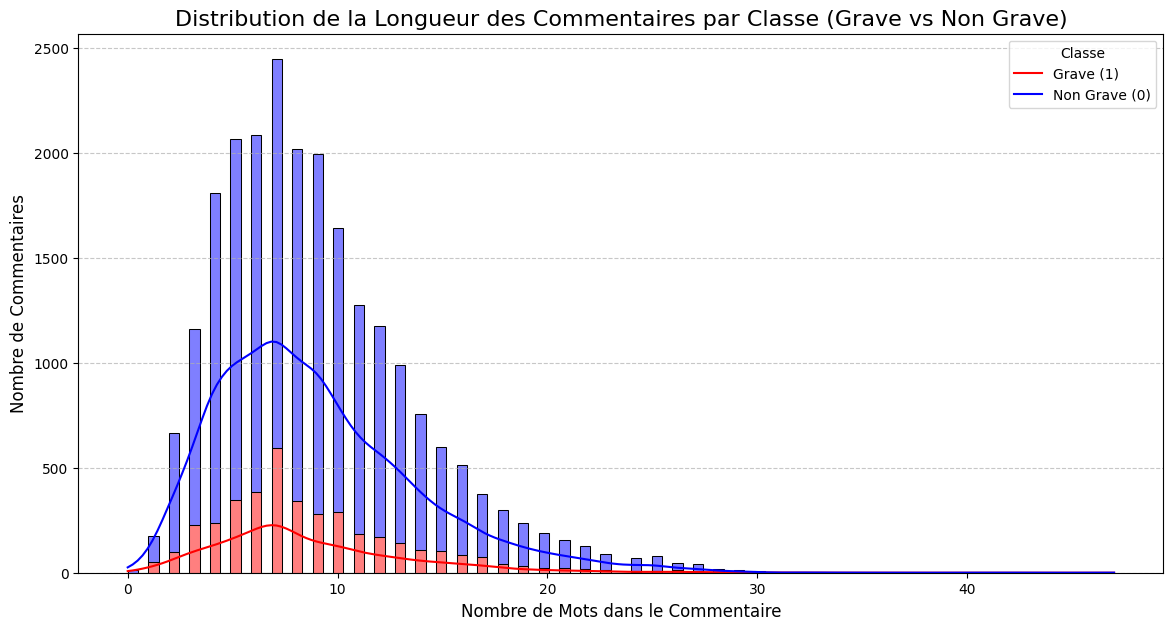

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- VISUALISATION 1: Distribution de la Longueur des Commentaires ---")

# Assurez-vous d'avoir une colonne avec le texte nettoyé, par exemple 'Avis_Cleaned'
# Si vous utilisez votre code V2, la colonne s'appelle 'Avis.Pharmaceutique_cleaned'
cleaned_text_column = 'Avis_Cleaned' # Adaptez si le nom de votre colonne est différent

# Calculez le nombre de mots pour chaque commentaire
data['comment_length'] = data[cleaned_text_column].apply(lambda x: len(x.split()))

# Créez une colonne temporaire pour la classe binaire afin de faciliter le tracé
data['is_grave'] = y_binary

# Créez l'histogramme avec des courbes de densité (KDE)
plt.figure(figsize=(14, 7))
sns.histplot(data=data, x='comment_length', hue='is_grave', kde=True,
             palette={0: 'blue', 1: 'red'}, multiple="stack")

plt.title('Distribution de la Longueur des Commentaires par Classe (Grave vs Non Grave)', fontsize=16)
plt.xlabel('Nombre de Mots dans le Commentaire', fontsize=12)
plt.ylabel('Nombre de Commentaires', fontsize=12)
plt.legend(title='Classe', labels=['Grave (1)', 'Non Grave (0)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#. Nuages de Mots par Classe


--- VISUALISATION 2: Nuages de Mots par Classe ---


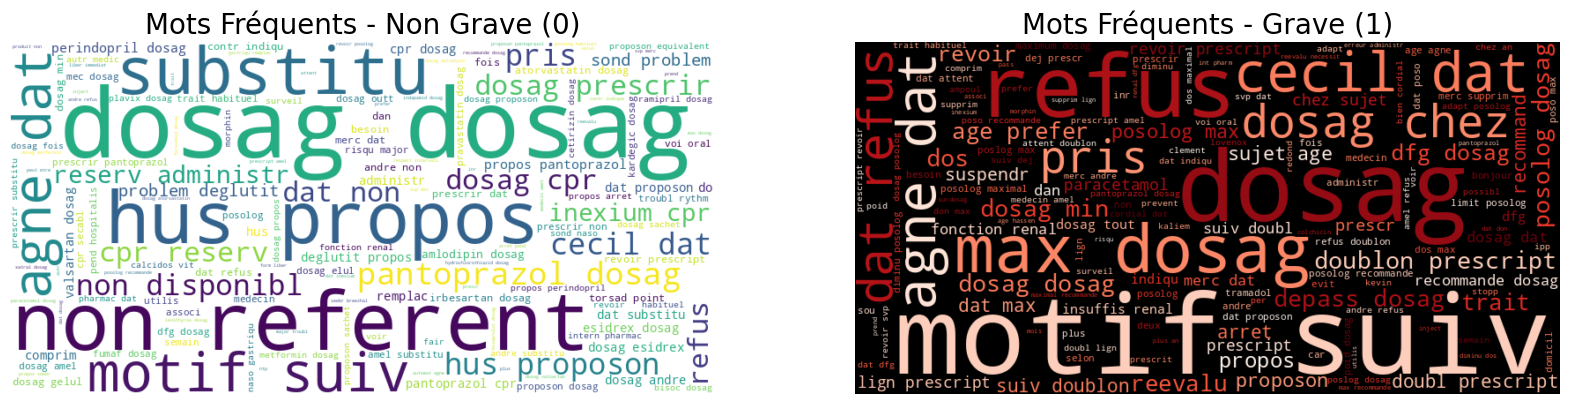

In [ ]:
from wordcloud import WordCloud
import nltk

print("\n--- VISUALISATION 2: Nuages de Mots par Classe ---")

# Assurez-vous que la liste de stopwords est disponible
try:
    french_stopwords = nltk.corpus.stopwords.words('french') + \
                      ['patient', 'traitement', 'prescription', 'jour', 'matin', 'soir']
except:
    nltk.download('stopwords')
    french_stopwords = nltk.corpus.stopwords.words('french') + \
                      ['patient', 'traitement', 'prescription', 'jour', 'matin', 'soir']


# Séparer les textes des deux classes
text_non_grave = " ".join(comment for comment, label in zip(data[cleaned_text_column], y_binary) if label == 0)
text_grave = " ".join(comment for comment, label in zip(data[cleaned_text_column], y_binary) if label == 1)

# Créer les nuages de mots
wordcloud_non_grave = WordCloud(stopwords=french_stopwords, background_color="white", max_words=150,
                                width=800, height=400, colormap='viridis').generate(text_non_grave)

wordcloud_grave = WordCloud(stopwords=french_stopwords, background_color="black", max_words=150,
                            width=800, height=400, colormap='Reds').generate(text_grave)

# Afficher les nuages côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

ax1.imshow(wordcloud_non_grave, interpolation='bilinear')
ax1.set_title('Mots Fréquents - Non Grave (0)', fontsize=20)
ax1.axis("off")

ax2.imshow(wordcloud_grave, interpolation='bilinear')
ax2.set_title('Mots Fréquents - Grave (1)', fontsize=20)
ax2.axis("off")

plt.show()

#Importance des Mots pour le Modèle


--- VISUALISATION 3: Importance des Mots pour le Modèle Linéaire dans le Pipeline ---


/tmp/ipython-input-1761728017.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, palette="vlag")


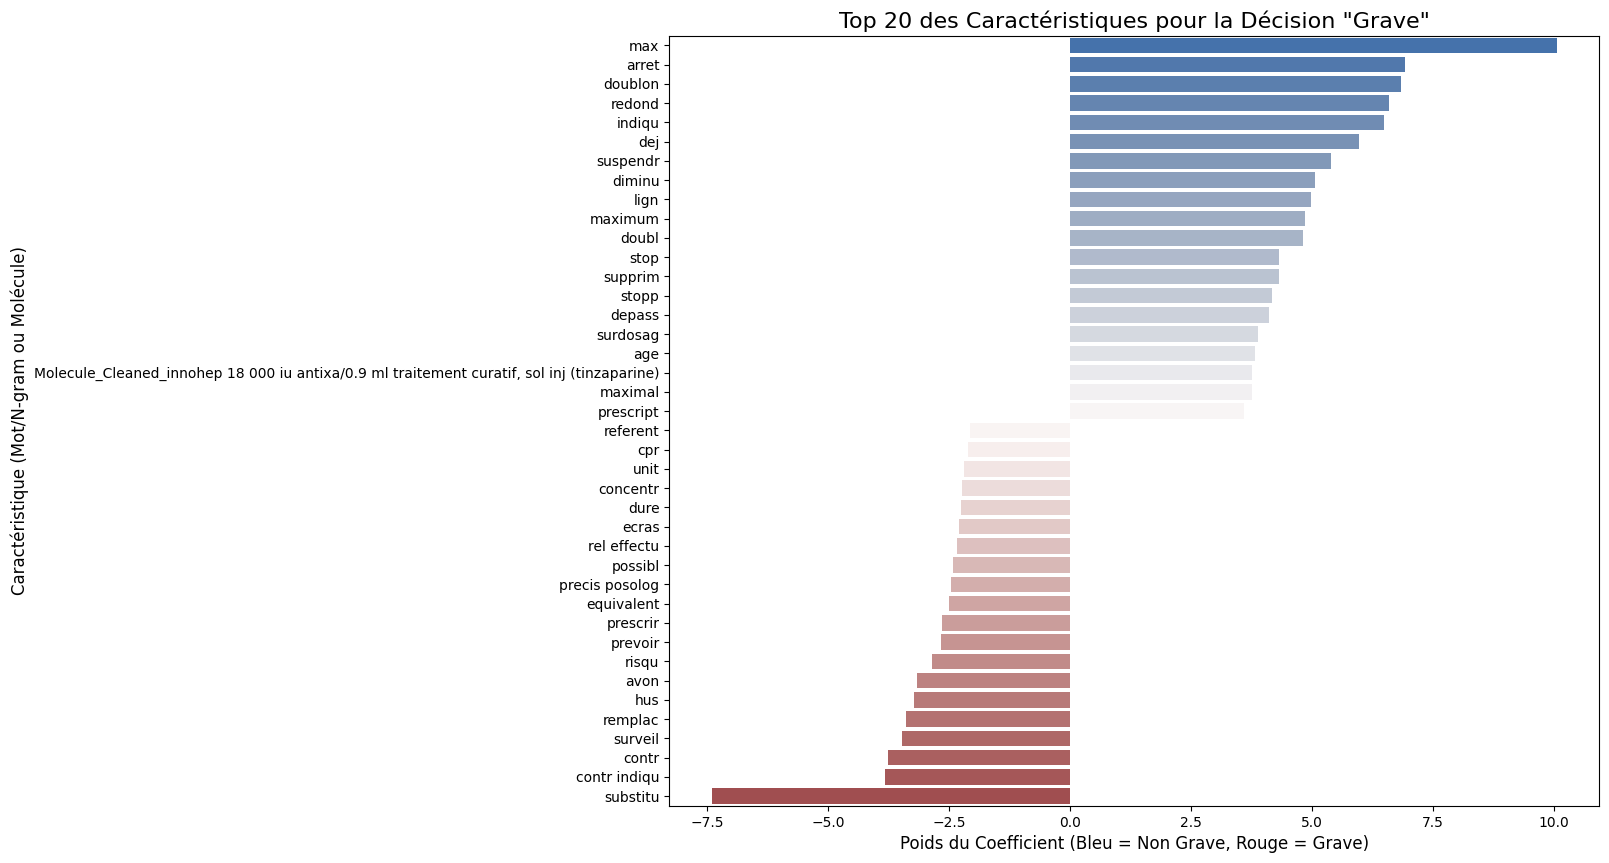

In [ ]:
# (Exécutez ce code après avoir entraîné votre `binary_pipeline`)

print("\n--- VISUALISATION 3: Importance des Mots pour le Modèle Linéaire dans le Pipeline ---")

# Extraire les étapes du pipeline
preprocessor_step = binary_pipeline.named_steps['preprocessor']
classifier_step = binary_pipeline.named_steps['classifier']

# Assurez-vous qu'un des modèles de l'ensemble est une Régression Logistique
try:
    logistic_model = classifier_step.named_estimators_['lr']

    # Récupérer les noms des features du TF-IDF
    tfidf_feature_names = preprocessor_step.named_transformers_['txt'].get_feature_names_out()
    # Récupérer les noms du OneHotEncoder (pour être complet)
    ohe_feature_names = preprocessor_step.named_transformers_['mol'].get_feature_names_out()

    # Concaténer tous les noms de features dans le bon ordre
    all_feature_names = np.concatenate([tfidf_feature_names, ohe_feature_names])

    # Extraire les coefficients du modèle
    coefficients = logistic_model.coef_[0]

    feature_importance = pd.DataFrame({'feature': all_feature_names, 'importance': coefficients})
    feature_importance = feature_importance.sort_values(by='importance', ascending=False)

    top_features = pd.concat([feature_importance.head(20), feature_importance.tail(20)])

    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=top_features, palette="vlag")
    plt.title('Top 20 des Caractéristiques pour la Décision "Grave"', fontsize=16)
    plt.xlabel('Poids du Coefficient (Bleu = Non Grave, Rouge = Grave)', fontsize=12)
    plt.ylabel('Caractéristique (Mot/N-gram ou Molécule)', fontsize=12)
    plt.show()

except KeyError:
    print("Le VotingClassifier n'a pas de modèle nommé 'lr' (LogisticRegression). Impossible de visualiser l'importance des mots de cette manière.")

#Analyse des Erreurs : Les Prédictions les Plus Incertaines

Pourquoi c'est utile ? Identifier les commentaires que votre modèle a le plus de mal à classer (ceux dont la probabilité est proche de 0.5) est une mine d'or. Cela vous montre les cas ambigus, les formulations complexes ou les sujets que le modèle ne maîtrise pas bien. C'est souvent là que vous trouverez des idées pour améliorer votre nettoyage de texte ou votre feature engineering.

In [ ]:
# (À exécuter après avoir obtenu `y_probas_test` de votre modèle binaire)

# Créer un DataFrame avec le texte original, la vraie classe, et la probabilité prédite
df_analysis = X_test.copy()
df_analysis['vraie_classe'] = y_test_bin
df_analysis['probabilite_grave'] = y_probas_test

# Calculer la "distance" par rapport au seuil de 0.5 (l'incertitude)
df_analysis['incertitude'] = np.abs(df_analysis['probabilite_grave'] - 0.5)

# Trier pour trouver les plus incertains (ceux les plus proches de 0.5)
df_incertains = df_analysis.sort_values(by='incertitude', ascending=True)

print("--- TOP 10 DES PRÉDICTIONS LES PLUS INCERTAINES ---")
# Afficher le texte original (non nettoyé) pour mieux comprendre
original_test_text = data['Avis.Pharmaceutique'].loc[df_incertains.index]

for i in range(10):
    idx = df_incertains.index[i]
    prob = df_incertains['probabilite_grave'].iloc[i]
    vraie = df_incertains['vraie_classe'].iloc[i]
    texte = original_test_text.loc[idx]

    print(f"#{i+1} | Probabilité 'Grave': {prob:.2f} | Vraie Classe: {vraie}")
    print(f"   Texte : \"{texte}\"\\n")

--- TOP 10 DES PRÉDICTIONS LES PLUS INCERTAINES ---
#1 | Probabilité 'Grave': 0.50 | Vraie Classe: 0
   Texte : "Refusé : Insuline rapide à adapter selon glycémie, pas de dose fixe.   17/01"\n
#2 | Probabilité 'Grave': 0.50 | Vraie Classe: 0
   Texte : "Refusé pour le motif suivant : patient sous CLOXACILLINE en IV PSE. Oxacilline IV non référencée aux HUS. De plus, posologie à 4g/j faible. A réévaluer.  - "\n
#3 | Probabilité 'Grave': 0.50 | Vraie Classe: 0
   Texte : "Avait Eliquis 5 mg 1-0-1 à la consultation de 12/2016 ; pas de raison d'adaptation de posologie. A réévaluer SVP.   interne en pharmacie 16/3/17"\n
#4 | Probabilité 'Grave': 0.50 | Vraie Classe: 0
   Texte : "1/2cp de COVERSYL 5mg équivaut à 1cp de PERINDOPRIL 2mg.   13/04/17"\n
#5 | Probabilité 'Grave': 0.50 | Vraie Classe: 1
   Texte : "05/04/17  DFG < 15 -> poso recommandée = 250 mg toutes les 8 à 12h (source: GPR).   "\n
#6 | Probabilité 'Grave': 0.50 | Vraie Classe: 0
   Texte : "versatis est normalement indiqué po

#Projection des Données en 2D avec t-SNE

Pourquoi c'est utile ? Vos données textuelles sont transformées en un espace de plusieurs milliers de dimensions (via TF-IDF). C'est impossible à visualiser. Le t-SNE (t-Distributed Stochastic Neighbor Embedding) est une technique de réduction de dimensionnalité qui projette ces données en 2D, en essayant de préserver la structure locale. Cela vous permet de "voir" comment les classes se regroupent ou se chevauchent.


--- VISUALISATION 4: Projection t-SNE des vecteurs TF-IDF ---


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.020s...
[t-SNE] Computed neighbors for 5000 samples in 9.820s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.424722
[t-SNE] KL divergence after 250 iterations with early exaggeration: 115.497597
[t-SNE] KL divergence after 300 iterations: 5.063545


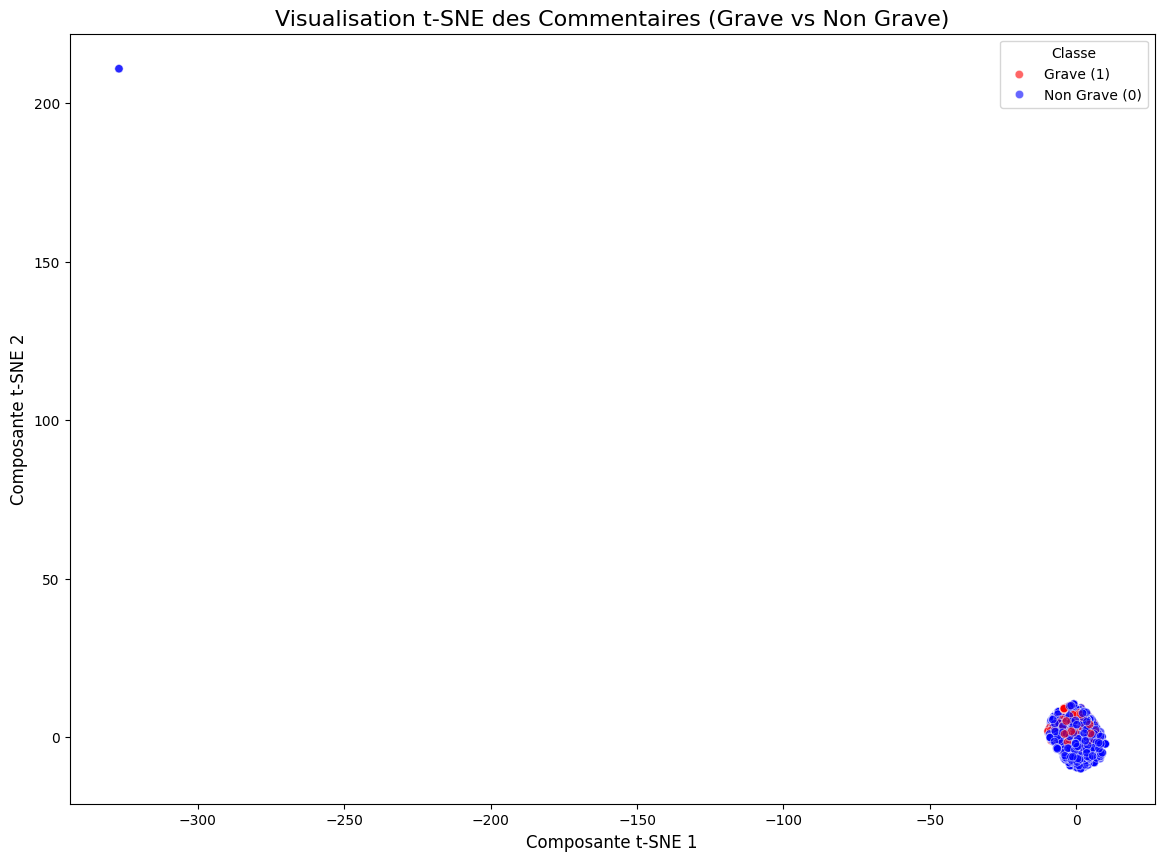

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- VISUALISATION 4: Projection t-SNE des vecteurs TF-IDF ---")

# Le t-SNE peut être lent, donc on prend un échantillon aléatoire (ex: 5000 points)
sample_size = min(5000, X_tfidf.shape[0])
sample_indices = np.random.choice(X_tfidf.shape[0], sample_size, replace=False)

X_sample = X_tfidf[sample_indices, :]
y_sample = y_binary.iloc[sample_indices]

# Initialiser et appliquer t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300, verbose=1)
X_tsne = tsne.fit_transform(X_sample.toarray()) # .toarray() est nécessaire pour les matrices sparse

# Créer le graphique
df_tsne = pd.DataFrame(X_tsne, columns=['Component 1', 'Component 2'])
df_tsne['classe'] = y_sample.values

plt.figure(figsize=(14, 10))
sns.scatterplot(
    x="Component 1", y="Component 2",
    hue="classe",
    palette={0: 'blue', 1: 'red'},
    data=df_tsne,
    legend="full",
    alpha=0.6
)

plt.title('Visualisation t-SNE des Commentaires (Grave vs Non Grave)', fontsize=16)
plt.xlabel('Composante t-SNE 1', fontsize=12)
plt.ylabel('Composante t-SNE 2', fontsize=12)
plt.legend(title='Classe', labels=['Grave (1)', 'Non Grave (0)'])
plt.show()